# Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
import lightgbm as lgb
import pickle
import re


# Loading Datasets

In [2]:
df = pd.read_csv('data_A (1).csv')


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22440 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21417 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

In [4]:
df.head()

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0xa658,CUS_0x936d,March,Alistair Barrs,8466,703-48-3482,_______,100433.58,8074.465000,...,Good,1023.93,33.471395,20 Years and 5 Months,No,100.163466,758.0704866746678,Low_spent_Medium_value_payments,229.21254743638283,Standard
1,1,0x6739,CUS_0x9a29,August,Phila,25,339-28-0072,Developer,33119.82,3024.985000,...,Bad,2545.0,33.810567,14 Years and 8 Months,Yes,111.422702,NaN,Low_spent_Small_value_payments,370.6074980582689,Poor
2,2,0xdcf5,CUS_0x12a9,April,Driverb,44,583-20-9758,_______,44822.21,3555.184167,...,Good,730.64,31.145739,23 Years and 10 Months,NM,135.044286,256.4742969677053,Low_spent_Medium_value_payments,243.99983412342044,Standard
3,3,0x14453,CUS_0x3bad,June,Prasadc,29,510-25-2095,Musician,142081.48,11771.123333,...,Standard,932.32,28.409526,27 Years and 0 Months,No,180.616478,423.96126196668365,Low_spent_Small_value_payments,862.534593039876,Standard
4,4,0x1198e,CUS_0xa3e1,January,Poornimai,45,943-92-4350,Scientist,19267.27_,1374.605833,...,Bad,3777.55,28.373426,10 Years and 3 Months,Yes,78.954825,133.56850235207634,Low_spent_Small_value_payments,214.93725572483646,Poor


# Data Preprocessing

## Drop useless column

In [5]:
df = df.drop('Unnamed: 0', axis=1)

In [6]:
df = df.drop(['ID','Name','SSN'], axis=1)

In [7]:
df = df.drop('Customer_ID', axis=1)

## Clean Numerical Column

In [8]:
def clean_string_to_float(col):
    return pd.to_numeric(df[col].astype(str).str.replace('[^0-9.]', '', regex=True), errors='coerce')

cols_to_fix = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment', 
               'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance']

for col in cols_to_fix:
    df[col] = clean_string_to_float(col)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  object 
 1   Age                       25000 non-null  int64  
 2   Occupation                25000 non-null  object 
 3   Annual_Income             25000 non-null  float64
 4   Monthly_Inhand_Salary     21417 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  int64  
 6   Num_Credit_Card           25000 non-null  int64  
 7   Interest_Rate             25000 non-null  int64  
 8   Num_of_Loan               25000 non-null  int64  
 9   Type_of_Loan              22172 non-null  object 
 10  Delay_from_due_date       25000 non-null  int64  
 11  Num_of_Delayed_Payment    23267 non-null  float64
 12  Changed_Credit_Limit      24482 non-null  float64
 13  Num_Credit_Inquiries      24494 non-null  float64
 14  Credit

## Check Duplicated Rows

In [10]:
df.duplicated().sum()

np.int64(0)

## Check Inconsistent Values

In [11]:

cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(f"--- Unique Values in {col} ---")
    print(df[col].value_counts())
    print("\n")

--- Unique Values in Month ---
Month
April       3173
July        3156
May         3151
March       3139
June        3131
August      3100
February    3087
January     3063
Name: count, dtype: int64


--- Unique Values in Occupation ---
Occupation
_______          1770
Engineer         1650
Lawyer           1618
Architect        1613
Media_Manager    1575
Accountant       1569
Entrepreneur     1559
Developer        1556
Scientist        1553
Teacher          1552
Mechanic         1529
Journalist       1523
Doctor           1519
Manager          1483
Musician         1474
Writer           1457
Name: count, dtype: int64


--- Unique Values in Type_of_Loan ---
Type_of_Loan
Not Specified                                                                                                   355
Credit-Builder Loan                                                                                             319
Debt Consolidation Loan                                                                  

## Clean Inconsistent Values

In [12]:
df['Occupation'] = df['Occupation'].replace('_______', 'Unknown')


In [13]:
df['Credit_Mix'] = df['Credit_Mix'].apply(lambda x: 'Unknown' if x == '_' or pd.isna(x) else x)

In [14]:
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', 'Unknown')

In [15]:
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', 'Unknown')

## Multi-Label Binarization for  Type_of_Loan Column

In [16]:

df['Type_of_Loan_Clean'] = df['Type_of_Loan'].str.replace('and ', '', regex=False).str.split(', ')

all_types = []
for row in df['Type_of_Loan_Clean'].dropna():
    all_types.extend([item.strip() for item in row])

unique_loan_types = set(all_types)
print(f"Type of Loan: {unique_loan_types}")

Type of Loan: {'Not Specified', 'Auto Loan', 'Credit-Builder Loan', 'Student Loan', 'Mortgage Loan', 'Personal Loan', 'Home Equity Loan', 'Payday Loan', 'Debt Consolidation Loan'}


In [17]:
unique_loan_types.discard('Not Specified')
unique_loan_types.discard('')

for loan in unique_loan_types:
    col_name = f"Loan_{loan.replace(' ', '_').replace('-', '_')}"
    df[col_name] = df['Type_of_Loan'].fillna('').apply(lambda x: 1 if loan in x else 0)

print(df[[col for col in df.columns if col.startswith('Loan_')]].head())

   Loan_Auto_Loan  Loan_Credit_Builder_Loan  Loan_Student_Loan  \
0               0                         0                  1   
1               0                         0                  0   
2               0                         1                  0   
3               0                         0                  0   
4               1                         0                  0   

   Loan_Mortgage_Loan  Loan_Personal_Loan  Loan_Home_Equity_Loan  \
0                   0                   0                      0   
1                   1                   0                      1   
2                   0                   0                      0   
3                   1                   1                      0   
4                   0                   0                      1   

   Loan_Payday_Loan  Loan_Debt_Consolidation_Loan  
0                 0                             1  
1                 0                             1  
2                 1                   

In [18]:
df = df.drop('Type_of_Loan', axis = 1)

In [19]:
df = df.drop('Type_of_Loan_Clean', axis=1)

In [20]:
df.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Monthly_Balance,Credit_Score,Loan_Auto_Loan,Loan_Credit_Builder_Loan,Loan_Student_Loan,Loan_Mortgage_Loan,Loan_Personal_Loan,Loan_Home_Equity_Loan,Loan_Payday_Loan,Loan_Debt_Consolidation_Loan
0,March,8466,Unknown,100433.58,8074.465000,1,5,10,2,13,...,229.212547,Standard,0,0,1,0,0,0,0,1
1,August,25,Developer,33119.82,3024.985000,10,5,32,5,50,...,370.607498,Poor,0,0,0,1,0,1,0,1
2,April,44,Unknown,44822.21,3555.184167,1,4,2,4,14,...,243.999834,Standard,0,1,0,0,0,0,1,1
3,June,29,Musician,142081.48,11771.123333,6,6,15,3,29,...,862.534593,Standard,0,0,0,1,1,0,0,0
4,January,45,Scientist,19267.27,1374.605833,10,8,25,6,33,...,214.937256,Poor,1,0,0,0,0,1,1,0


## Feature Engineering for Credit_History_Age

In [21]:
df['Credit_History_Months'] = df['Credit_History_Age'].apply(
    lambda x: (int(re.findall(r'\d+', str(x))[0]) * 12 + int(re.findall(r'\d+', str(x))[1])) 
    if pd.notna(x) and len(re.findall(r'\d+', str(x))) == 2 else np.nan
)

In [22]:
df.drop('Credit_History_Age', axis=1, inplace=True)

In [23]:
df.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Credit_Score,Loan_Auto_Loan,Loan_Credit_Builder_Loan,Loan_Student_Loan,Loan_Mortgage_Loan,Loan_Personal_Loan,Loan_Home_Equity_Loan,Loan_Payday_Loan,Loan_Debt_Consolidation_Loan,Credit_History_Months
0,March,8466,Unknown,100433.58,8074.465000,1,5,10,2,13,...,Standard,0,0,1,0,0,0,0,1,245.0
1,August,25,Developer,33119.82,3024.985000,10,5,32,5,50,...,Poor,0,0,0,1,0,1,0,1,176.0
2,April,44,Unknown,44822.21,3555.184167,1,4,2,4,14,...,Standard,0,1,0,0,0,0,1,1,286.0
3,June,29,Musician,142081.48,11771.123333,6,6,15,3,29,...,Standard,0,0,0,1,1,0,0,0,324.0
4,January,45,Scientist,19267.27,1374.605833,10,8,25,6,33,...,Poor,1,0,0,0,0,1,1,0,123.0


## Checking Anomaly

In [24]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Monthly_Balance,Loan_Auto_Loan,Loan_Credit_Builder_Loan,Loan_Student_Loan,Loan_Mortgage_Loan,Loan_Personal_Loan,Loan_Home_Equity_Loan,Loan_Payday_Loan,Loan_Debt_Consolidation_Loan,Credit_History_Months
count,25000.000000,2.500000e+04,21417.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,23267.000000,24482.000000,...,2.471100e+04,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,22751.000000
mean,114.246600,1.918058e+05,4215.671131,17.235440,22.143080,71.214040,10.679240,21.192000,30.420209,10.454362,...,5.395708e+22,0.305400,0.31952,0.309880,0.321320,0.315040,0.316200,0.318520,0.30992,220.614786
std,661.820409,1.531878e+06,3187.623134,118.307474,127.701822,463.669065,60.910626,14.887254,222.614181,6.654462,...,4.240697e+24,0.460586,0.46630,0.462453,0.466993,0.464541,0.465001,0.465912,0.46247,99.335388
min,14.000000,7.005930e+03,303.645417,-1.000000,0.000000,1.000000,0.000000,-5.000000,0.000000,0.010000,...,8.993352e-01,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000
25%,25.000000,1.955945e+04,1634.720833,4.000000,4.000000,8.000000,2.000000,10.000000,9.000000,5.310000,...,2.702622e+02,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,145.000000
50%,33.000000,3.781363e+04,3111.437500,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.440000,...,3.368486e+02,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,219.000000
75%,42.000000,7.309678e+04,5986.647500,7.000000,7.000000,20.000000,6.000000,28.000000,18.000000,14.827500,...,4.692803e+02,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,301.000000
max,8698.000000,2.418881e+07,15167.180000,1798.000000,1499.000000,5775.000000,1482.000000,67.000000,4388.000000,36.290000,...,3.333333e+26,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,404.000000


In [25]:
median_age = df.loc[df['Age'] <= 100, 'Age'].median()

df.loc[df['Age'] > 100, 'Age'] = median_age

In [26]:
df['Num_Bank_Accounts'] = df['Num_Bank_Accounts'].abs()
df['Delay_from_due_date'] = df['Delay_from_due_date'].abs()

In [27]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Monthly_Balance,Loan_Auto_Loan,Loan_Credit_Builder_Loan,Loan_Student_Loan,Loan_Mortgage_Loan,Loan_Personal_Loan,Loan_Home_Equity_Loan,Loan_Payday_Loan,Loan_Debt_Consolidation_Loan,Credit_History_Months
count,25000.000000,2.500000e+04,21417.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,23267.000000,24482.000000,...,2.471100e+04,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,22751.000000
mean,33.233400,1.918058e+05,4215.671131,17.235760,22.143080,71.214040,10.679240,21.221760,30.420209,10.454362,...,5.395708e+22,0.305400,0.31952,0.309880,0.321320,0.315040,0.316200,0.318520,0.30992,220.614786
std,10.666818,1.531878e+06,3187.623134,118.307428,127.701822,463.669065,60.910626,14.844798,222.614181,6.654462,...,4.240697e+24,0.460586,0.46630,0.462453,0.466993,0.464541,0.465001,0.465912,0.46247,99.335388
min,14.000000,7.005930e+03,303.645417,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000,...,8.993352e-01,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000
25%,25.000000,1.955945e+04,1634.720833,4.000000,4.000000,8.000000,2.000000,10.000000,9.000000,5.310000,...,2.702622e+02,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,145.000000
50%,33.000000,3.781363e+04,3111.437500,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.440000,...,3.368486e+02,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,219.000000
75%,41.000000,7.309678e+04,5986.647500,7.000000,7.000000,20.000000,6.000000,28.000000,18.000000,14.827500,...,4.692803e+02,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,301.000000
max,95.000000,2.418881e+07,15167.180000,1798.000000,1499.000000,5775.000000,1482.000000,67.000000,4388.000000,36.290000,...,3.333333e+26,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,404.000000


## EDA

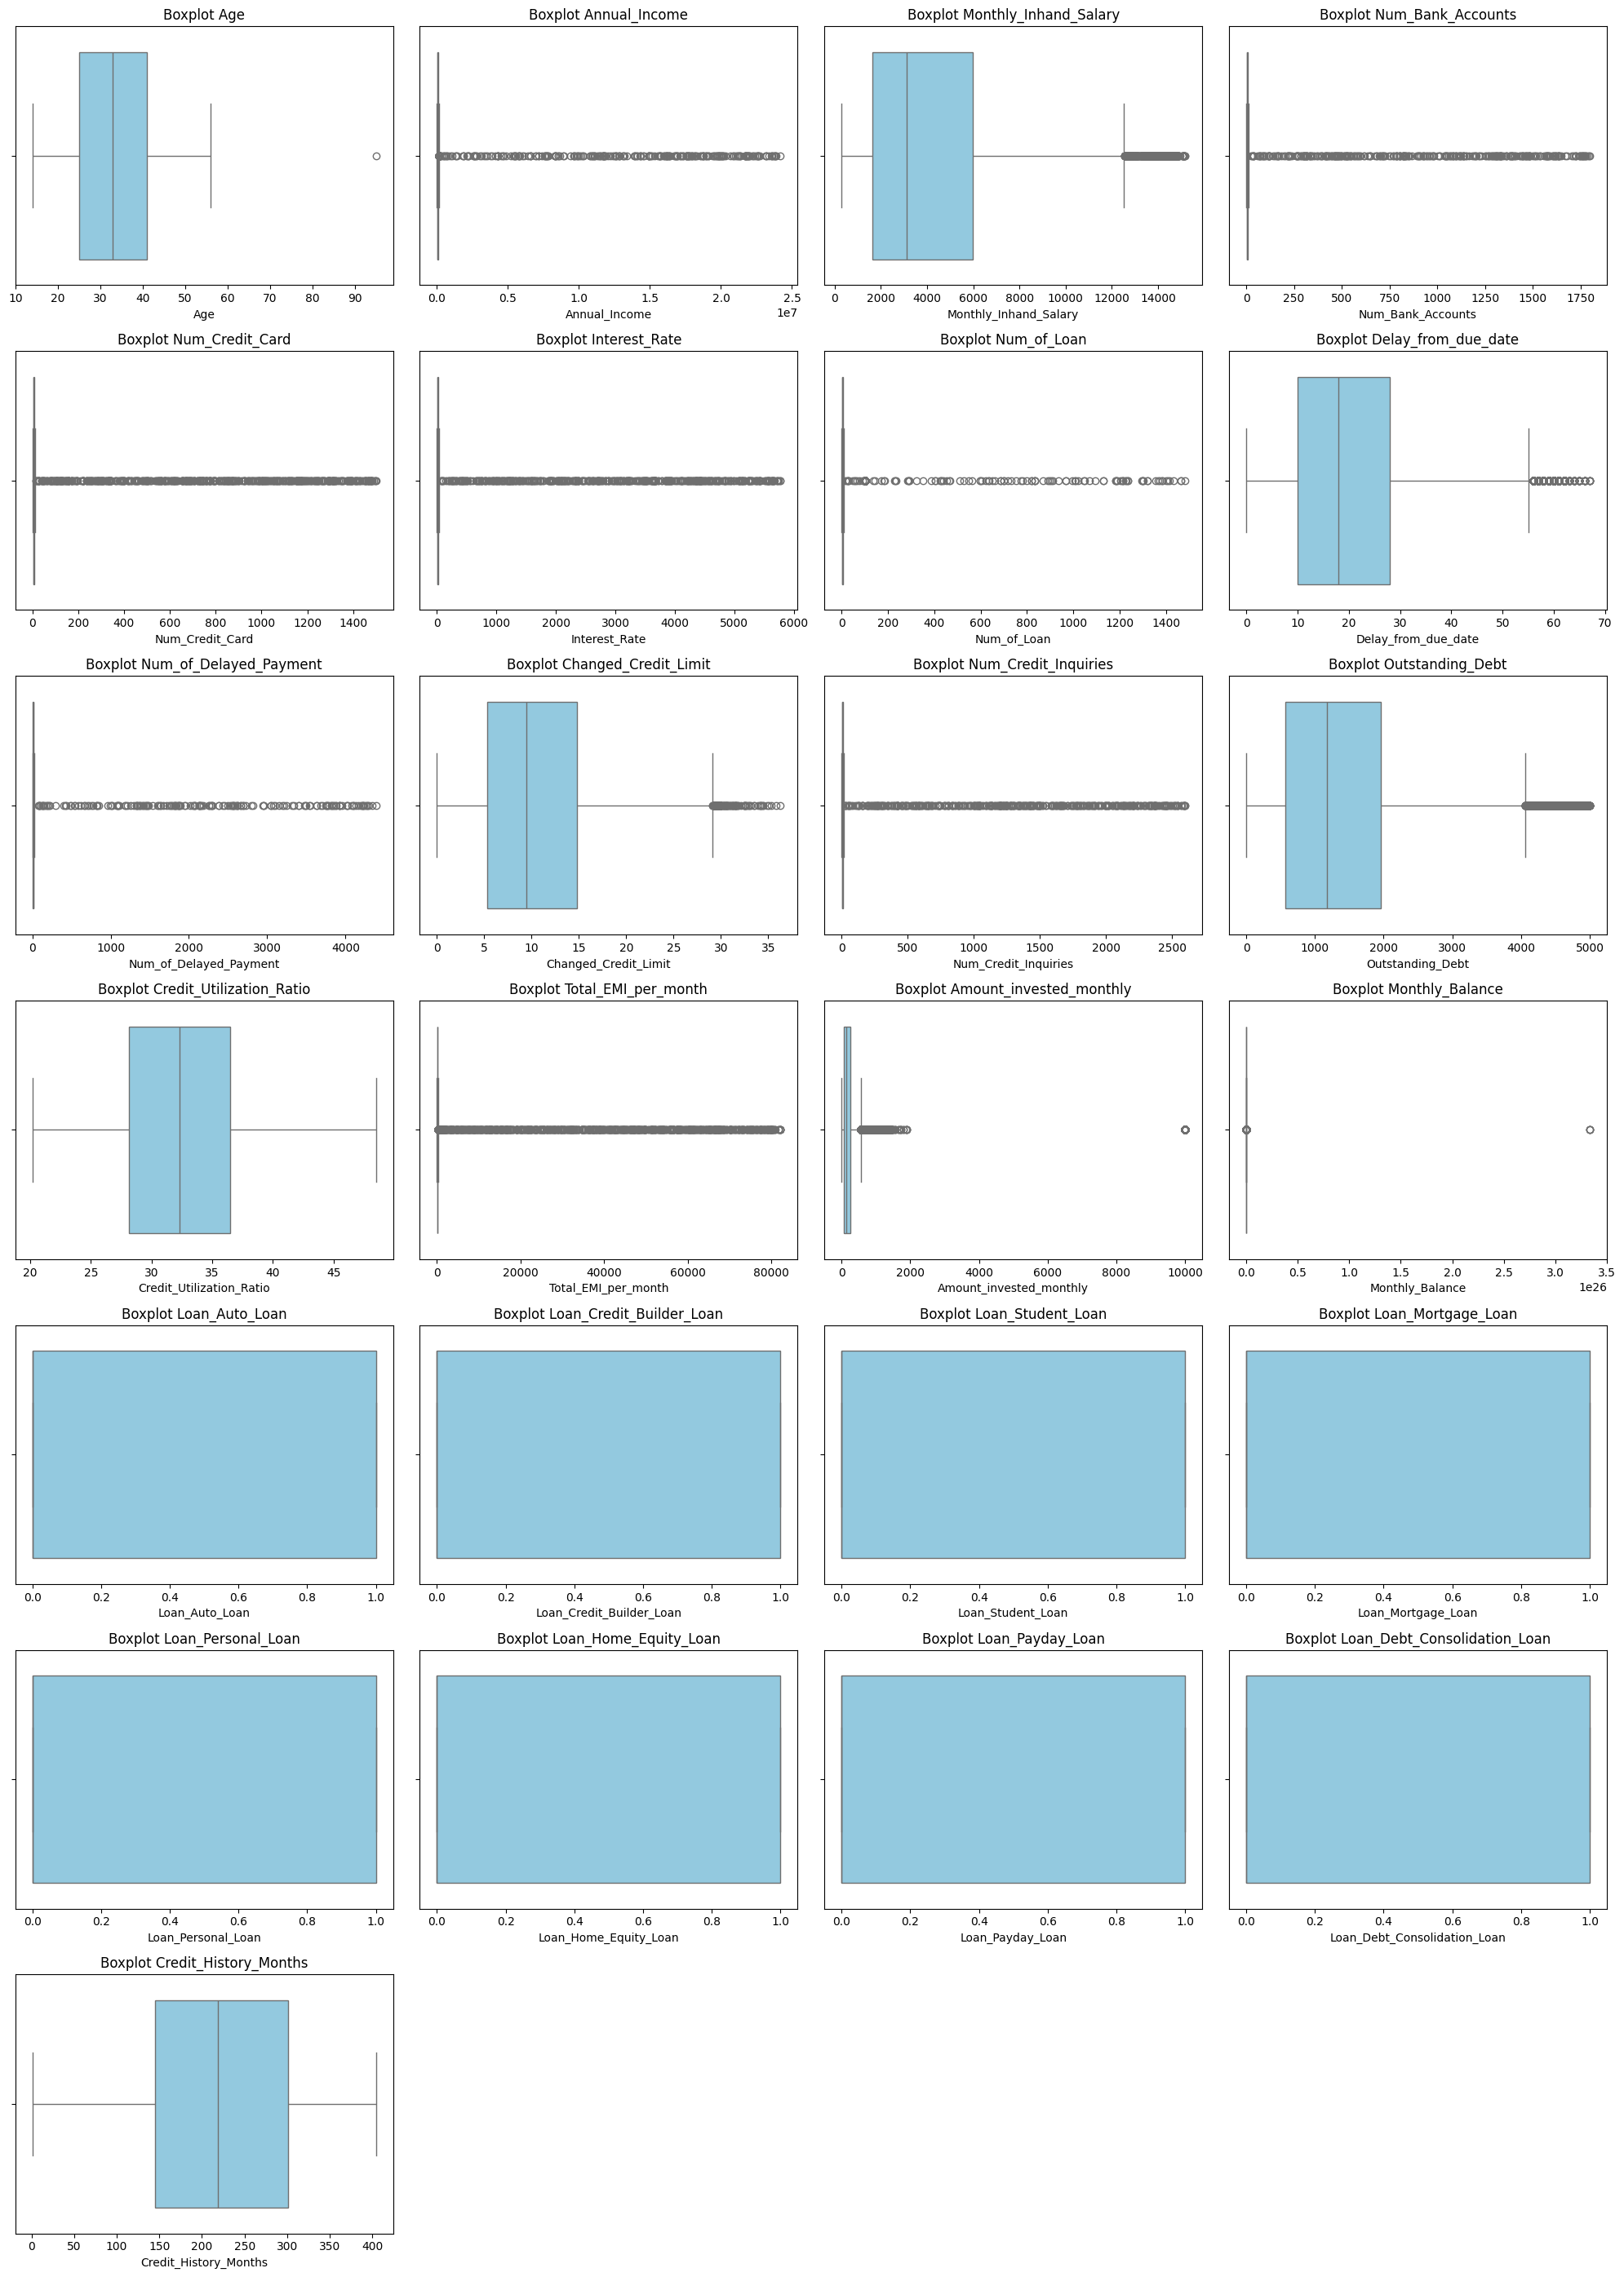

In [28]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

n_rows = (len(num_cols) // 4) + 1
plt.figure(figsize=(20, n_rows * 4))
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, 4, i + 1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot {col}', fontsize=12)
    plt.tight_layout()

plt.show()

C:\Users\andro\AppData\Local\Temp\ipykernel_32232\37807565.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Credit_Score', data=df, palette='viridis')


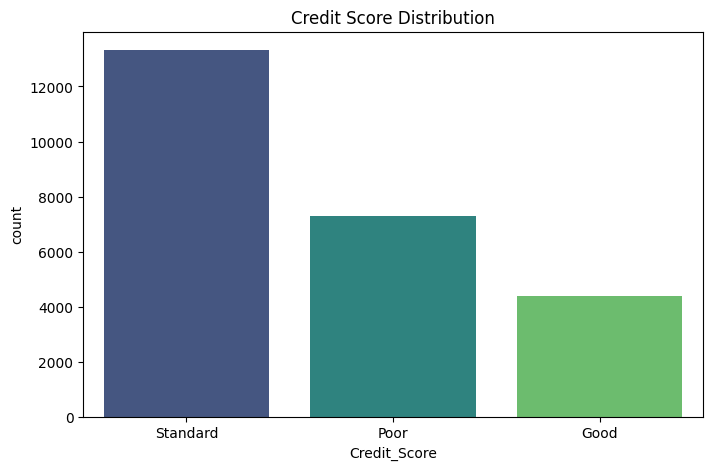

In [29]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Credit_Score', data=df, palette='viridis')
plt.title('Credit Score Distribution')
plt.show()

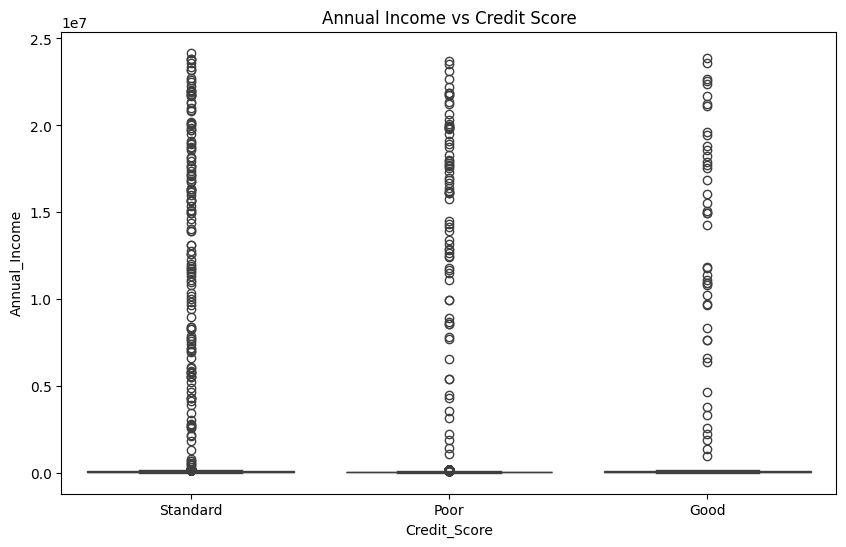

In [30]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Credit_Score', y='Annual_Income', data=df)
plt.title('Annual Income vs Credit Score')
plt.show()

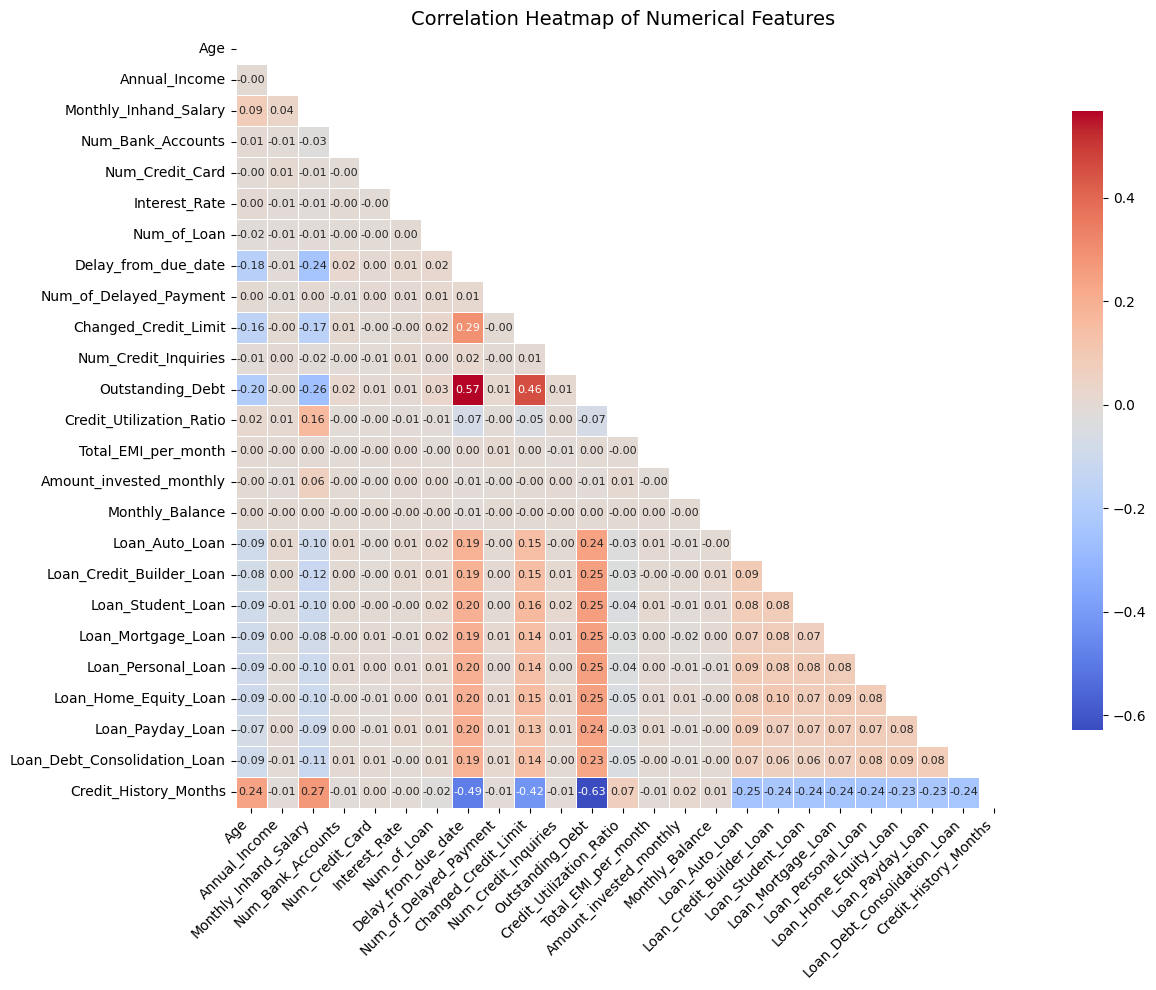

In [31]:
plt.figure(figsize=(14, 10))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8}
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()


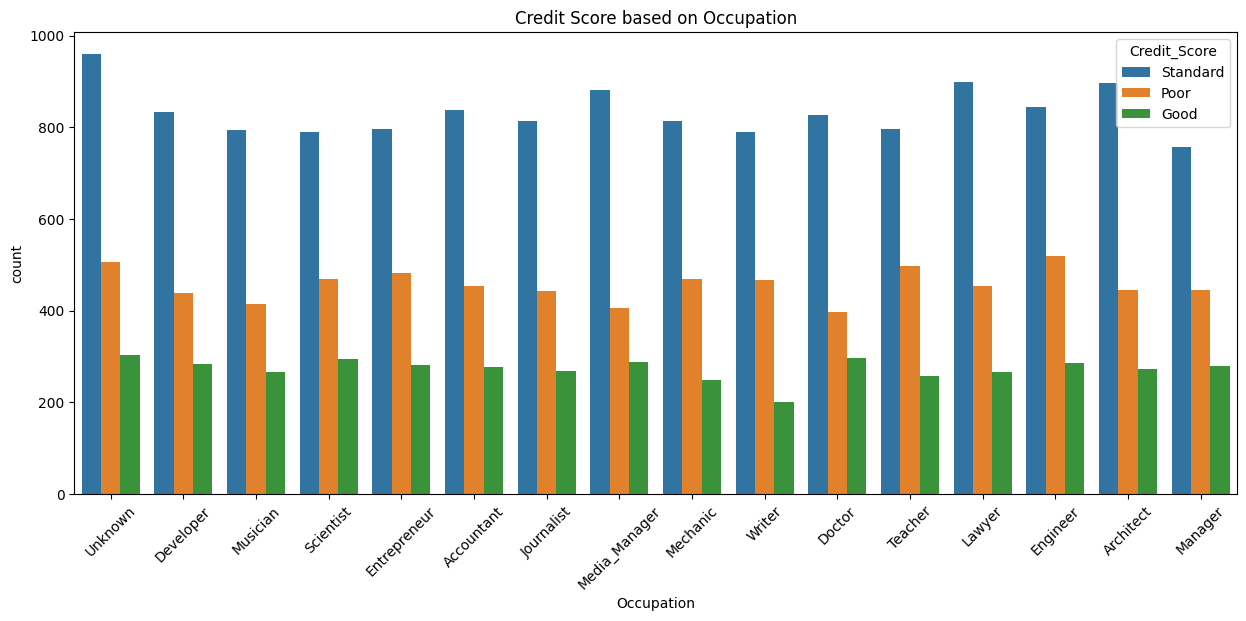

In [32]:
plt.figure(figsize=(15, 6))
sns.countplot(x='Occupation', hue='Credit_Score', data=df)
plt.xticks(rotation=45)
plt.title('Credit Score based on Occupation')
plt.show()

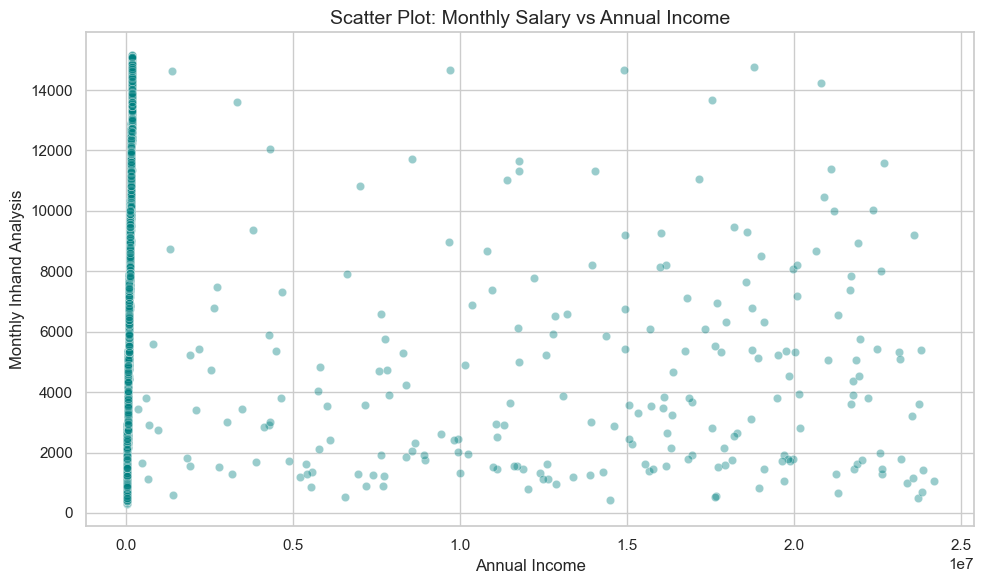

In [33]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df['Annual_Income'], 
    y = df['Monthly_Inhand_Salary'],
    alpha=0.4, 
    color='teal'
)

plt.title('Scatter Plot: Monthly Salary vs Annual Income', fontsize=14)
plt.xlabel('Annual Income', fontsize=12)
plt.ylabel('Monthly Inhand Analysis', fontsize=12)

plt.tight_layout()
plt.show()


In [34]:
## Anomaly Check - Distribusi Percentile P95 hingga P99
 
suspect_cols = [
    'Annual_Income',
    'Monthly_Balance',
    'Num_Bank_Accounts',
    'Num_Credit_Card', 
    'Interest_Rate',
    'Num_of_Loan',
    'Num_Credit_Inquiries',
    'Num_of_Delayed_Payment',
    'Total_EMI_per_month',
]
 
# Header
print(f"{'Kolom':<30} {'P95':>12} {'P96':>12} {'P97':>12} {'P98':>12} {'P99':>12} {'Max':>15} {'> P99':>8} {'% Total':>8}")
print("-" * 125)
 
for col in suspect_cols:
    p95 = df[col].quantile(0.95)
    p96 = df[col].quantile(0.96)
    p97 = df[col].quantile(0.97)
    p98 = df[col].quantile(0.98)
    p99 = df[col].quantile(0.99)
    max_val = df[col].max()
    count_above = (df[col] > p99).sum()
    pct = count_above / len(df) * 100
    print(f"{col:<30} {p95:>12,.2f} {p96:>12,.2f} {p97:>12,.2f} {p98:>12,.2f} {p99:>12,.2f} {max_val:>15,.2f} {count_above:>8} {pct:>7.2f}%")

Kolom                                   P95          P96          P97          P98          P99             Max    > P99  % Total
-----------------------------------------------------------------------------------------------------------------------------
Annual_Income                    134,928.36   142,170.43   150,625.48   167,258.04 1,895,719.48   24,188,807.00      250    1.00%
Monthly_Balance                      862.31       911.40       963.66     1,032.64     1,129.28 333,333,333,333,333,314,856,026,112.00      248    0.99%
Num_Bank_Accounts                     10.00        10.00        10.00        10.00       442.05        1,798.00      250    1.00%
Num_Credit_Card                       10.00        10.00        10.00       147.00       824.01        1,499.00      250    1.00%
Interest_Rate                         32.00        33.00        34.00        34.00     2,889.07        5,775.00      250    1.00%
Num_of_Loan                            9.00       100.00       100.00  

In [35]:
caps = {
    'Annual_Income'         : df['Annual_Income'].quantile(0.98),         # 167k
    'Num_Bank_Accounts'     : df['Num_Bank_Accounts'].quantile(0.98),     # 10
    'Num_Credit_Card'       : df['Num_Credit_Card'].quantile(0.95),       # 10
    'Interest_Rate'         : df['Interest_Rate'].quantile(0.95),         # 32%
    'Num_of_Loan'           : df['Num_of_Loan'].quantile(0.95),           # 9
    'Num_Credit_Inquiries'  : df['Num_Credit_Inquiries'].quantile(0.98),  # 16
    'Num_of_Delayed_Payment': df['Num_of_Delayed_Payment'].quantile(0.99),# 27 (ok)
    'Total_EMI_per_month'   : df['Total_EMI_per_month'].quantile(0.95),   # 446
}

for col, cap_val in caps.items():
    df.loc[df[col] > cap_val, col] = cap_val

In [36]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Monthly_Balance,Loan_Auto_Loan,Loan_Credit_Builder_Loan,Loan_Student_Loan,Loan_Mortgage_Loan,Loan_Personal_Loan,Loan_Home_Equity_Loan,Loan_Payday_Loan,Loan_Debt_Consolidation_Loan,Credit_History_Months
count,25000.000000,25000.000000,21417.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,23267.000000,24482.000000,...,2.471100e+04,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,22751.000000
mean,33.233400,51810.998483,4215.671131,5.437920,5.637600,14.87356,3.798480,21.221760,13.485065,10.454362,...,5.395708e+22,0.305400,0.31952,0.309880,0.321320,0.315040,0.316200,0.318520,0.30992,220.614786
std,10.666818,39766.410523,3187.623134,2.621988,2.155971,8.89979,2.646626,14.844798,6.335072,6.654462,...,4.240697e+24,0.460586,0.46630,0.462453,0.466993,0.464541,0.465001,0.465912,0.46247,99.335388
min,14.000000,7005.930000,303.645417,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.010000,...,8.993352e-01,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000
25%,25.000000,19559.450000,1634.720833,4.000000,4.000000,8.00000,2.000000,10.000000,9.000000,5.310000,...,2.702622e+02,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,145.000000
50%,33.000000,37813.630000,3111.437500,6.000000,5.000000,13.00000,3.000000,18.000000,14.000000,9.440000,...,3.368486e+02,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,219.000000
75%,41.000000,73096.780000,5986.647500,7.000000,7.000000,20.00000,6.000000,28.000000,18.000000,14.827500,...,4.692803e+02,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,301.000000
max,95.000000,167258.040000,15167.180000,10.000000,10.000000,32.00000,9.000000,67.000000,27.000000,36.290000,...,3.333333e+26,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,404.000000


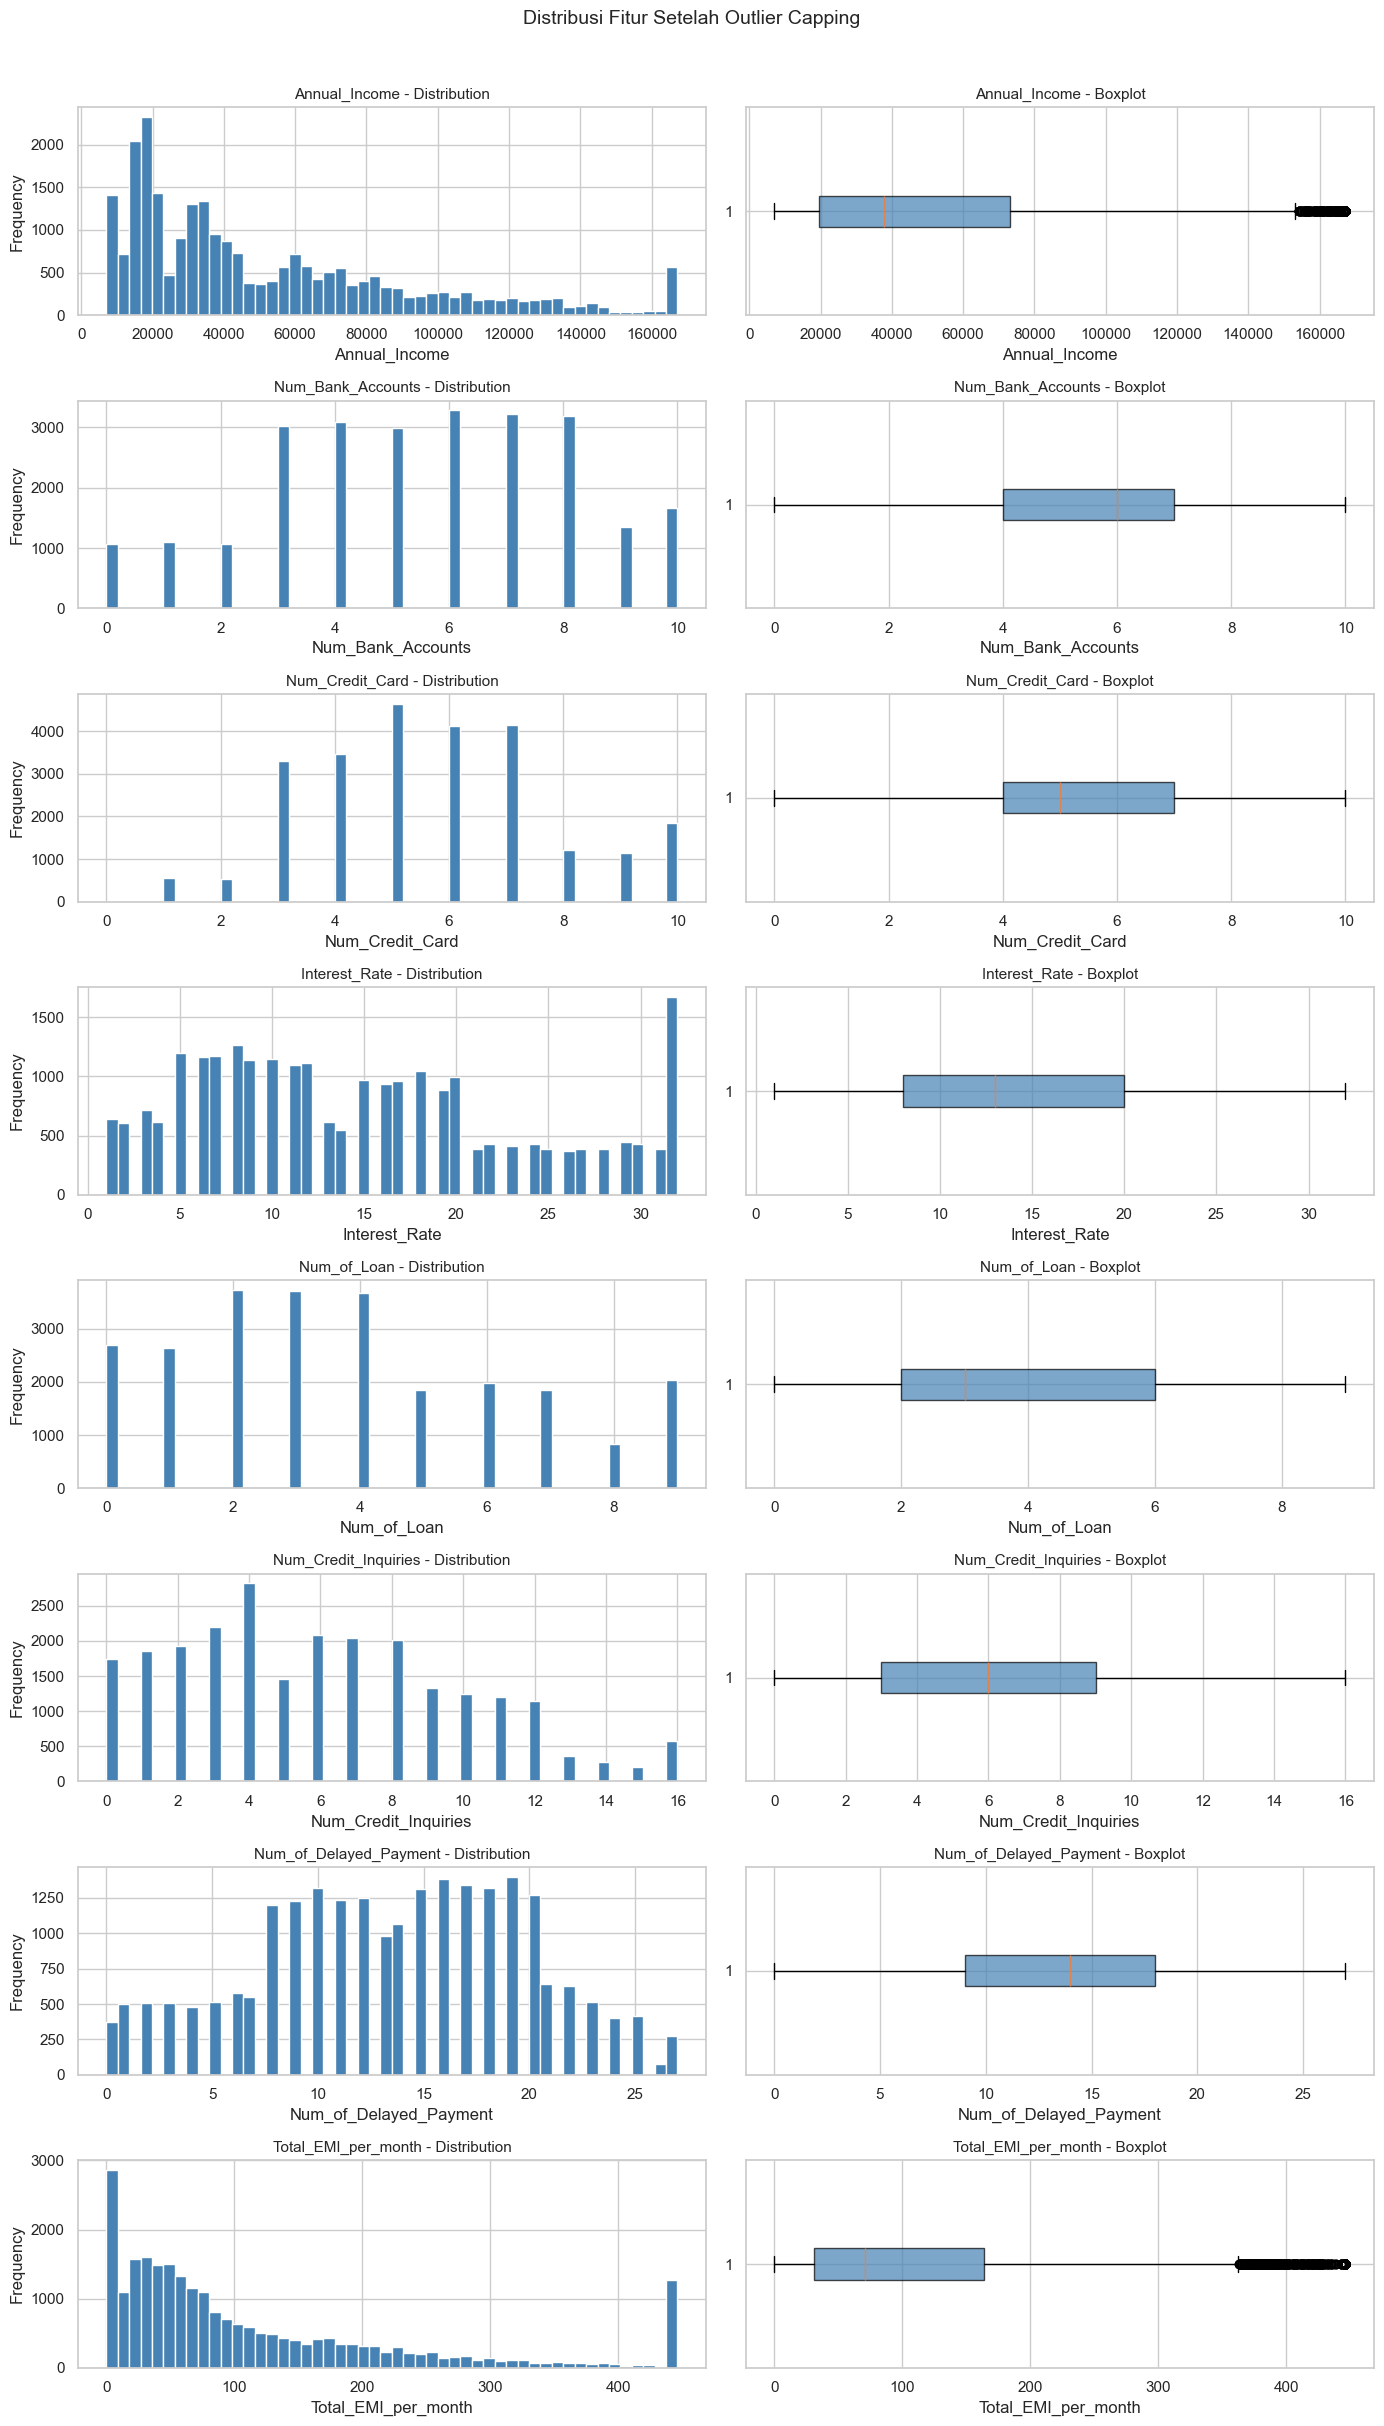

In [37]:
cap_cols = list(caps.keys())
 
fig, axes = plt.subplots(len(cap_cols), 2, figsize=(14, len(cap_cols) * 3))
 
for i, col in enumerate(cap_cols):
    data = df[col].dropna()
    
    # Histogram
    axes[i, 0].hist(data, bins=50, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'{col} - Distribution', fontsize=11)
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')
 
    # Boxplot
    axes[i, 1].boxplot(data, vert=False, patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i, 1].set_title(f'{col} - Boxplot', fontsize=11)
    axes[i, 1].set_xlabel(col)
 
plt.suptitle('Distribusi Fitur Setelah Outlier Capping', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

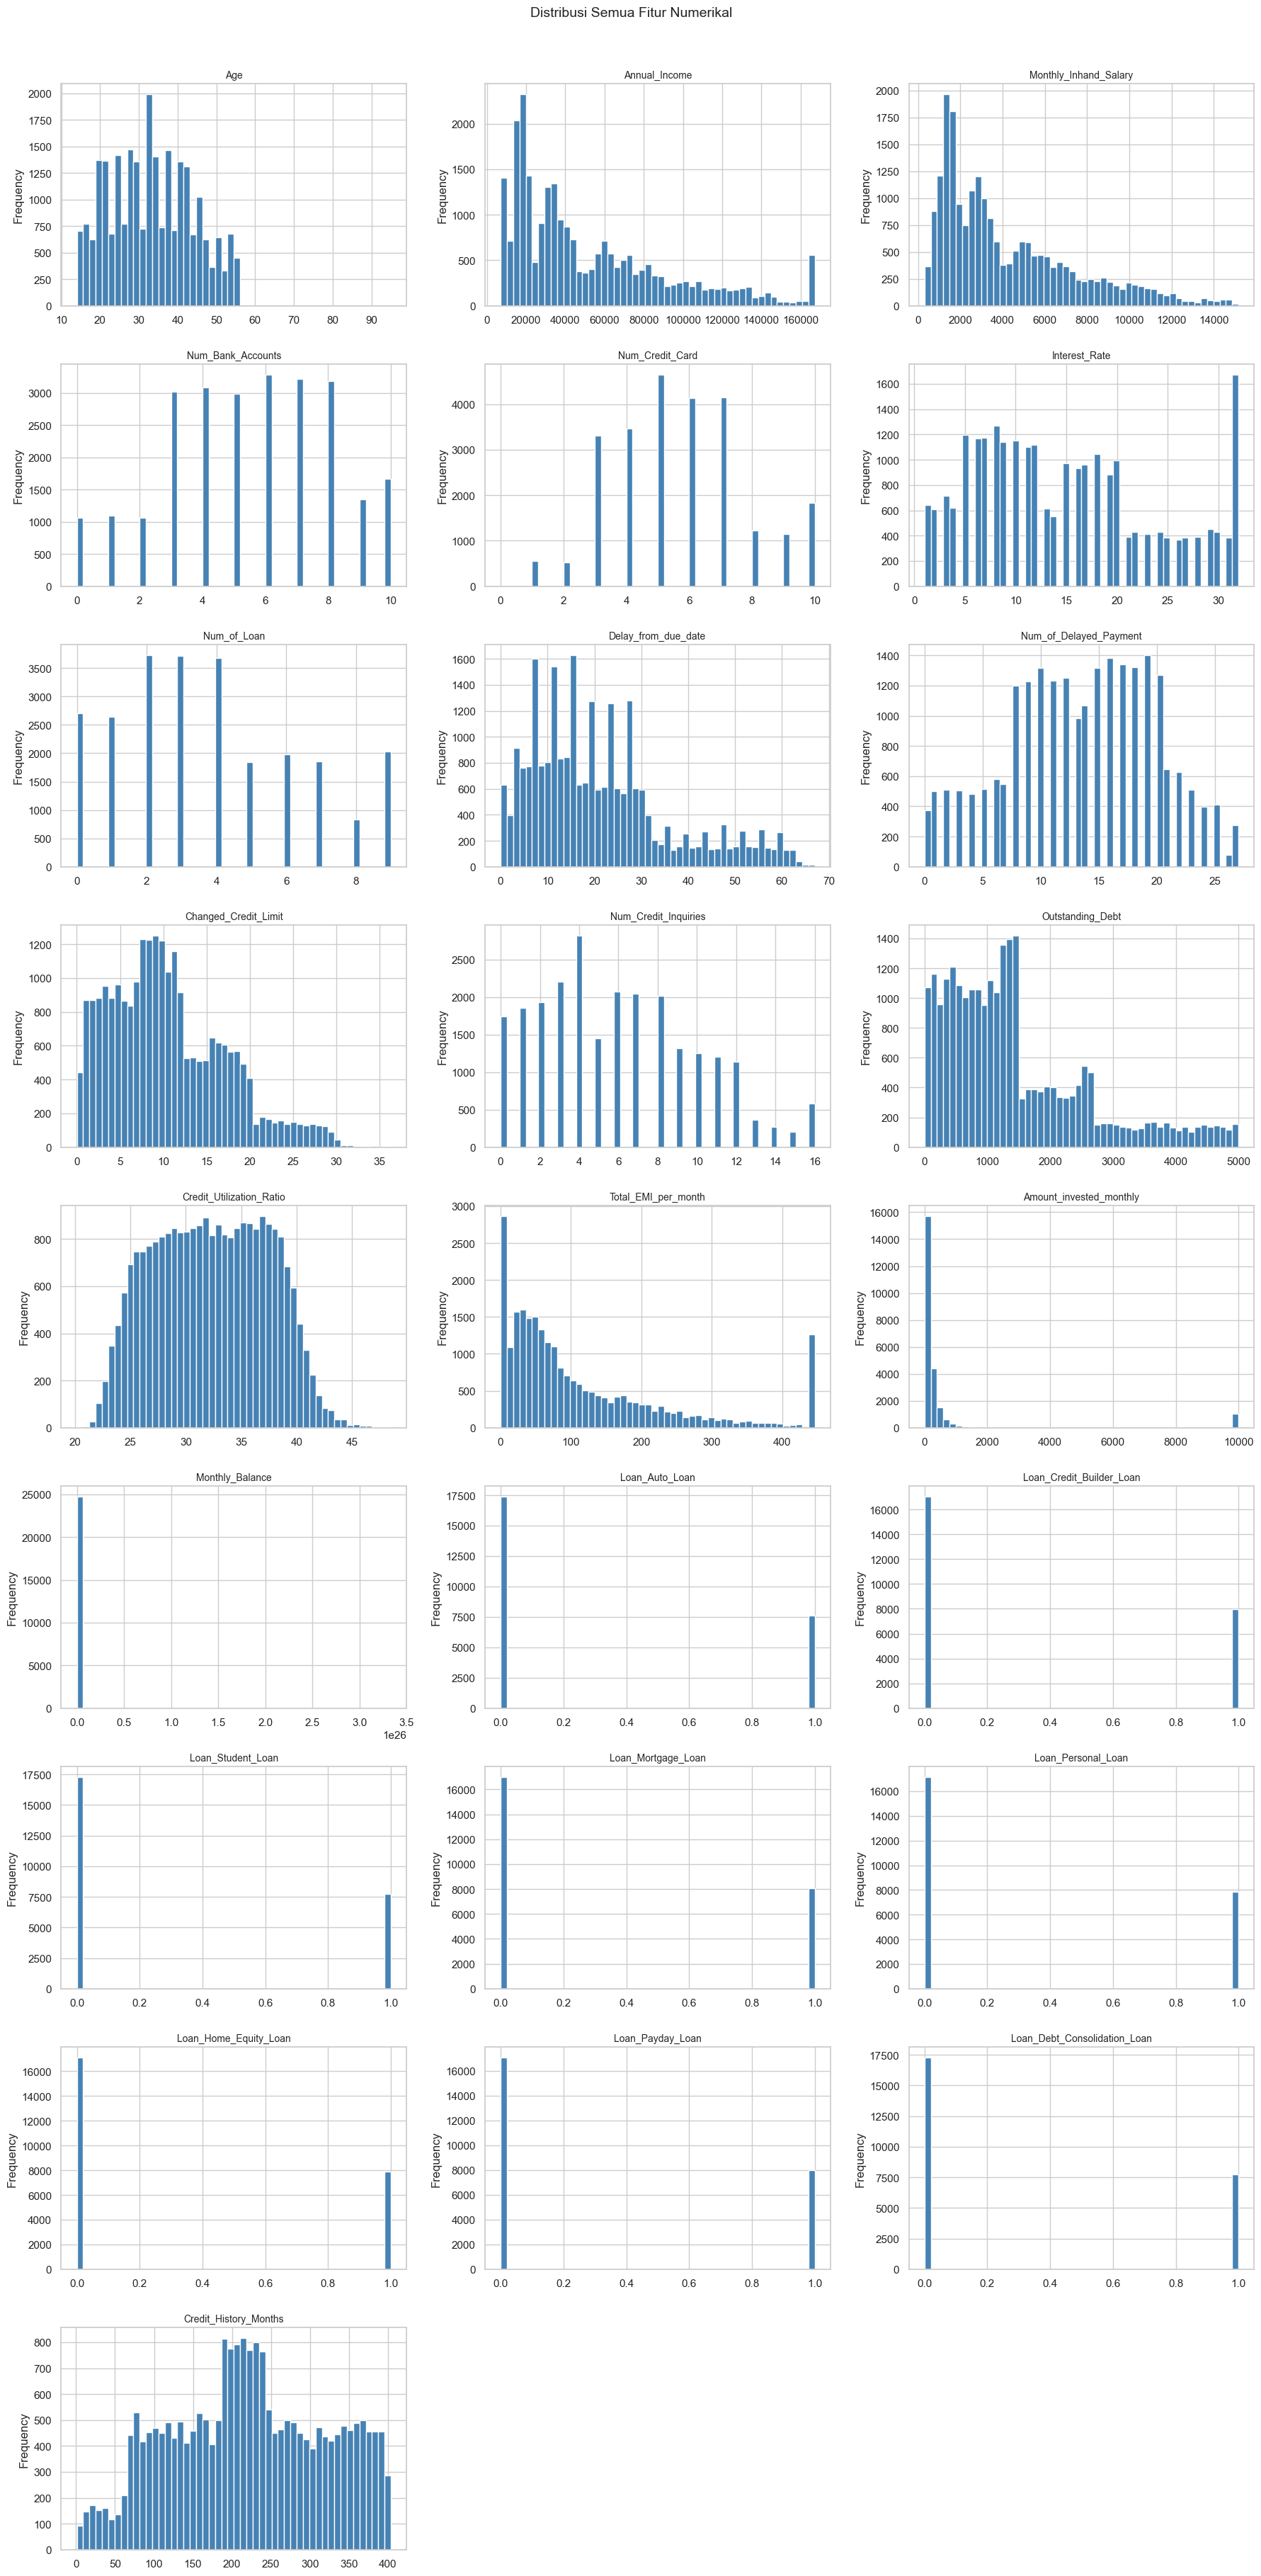

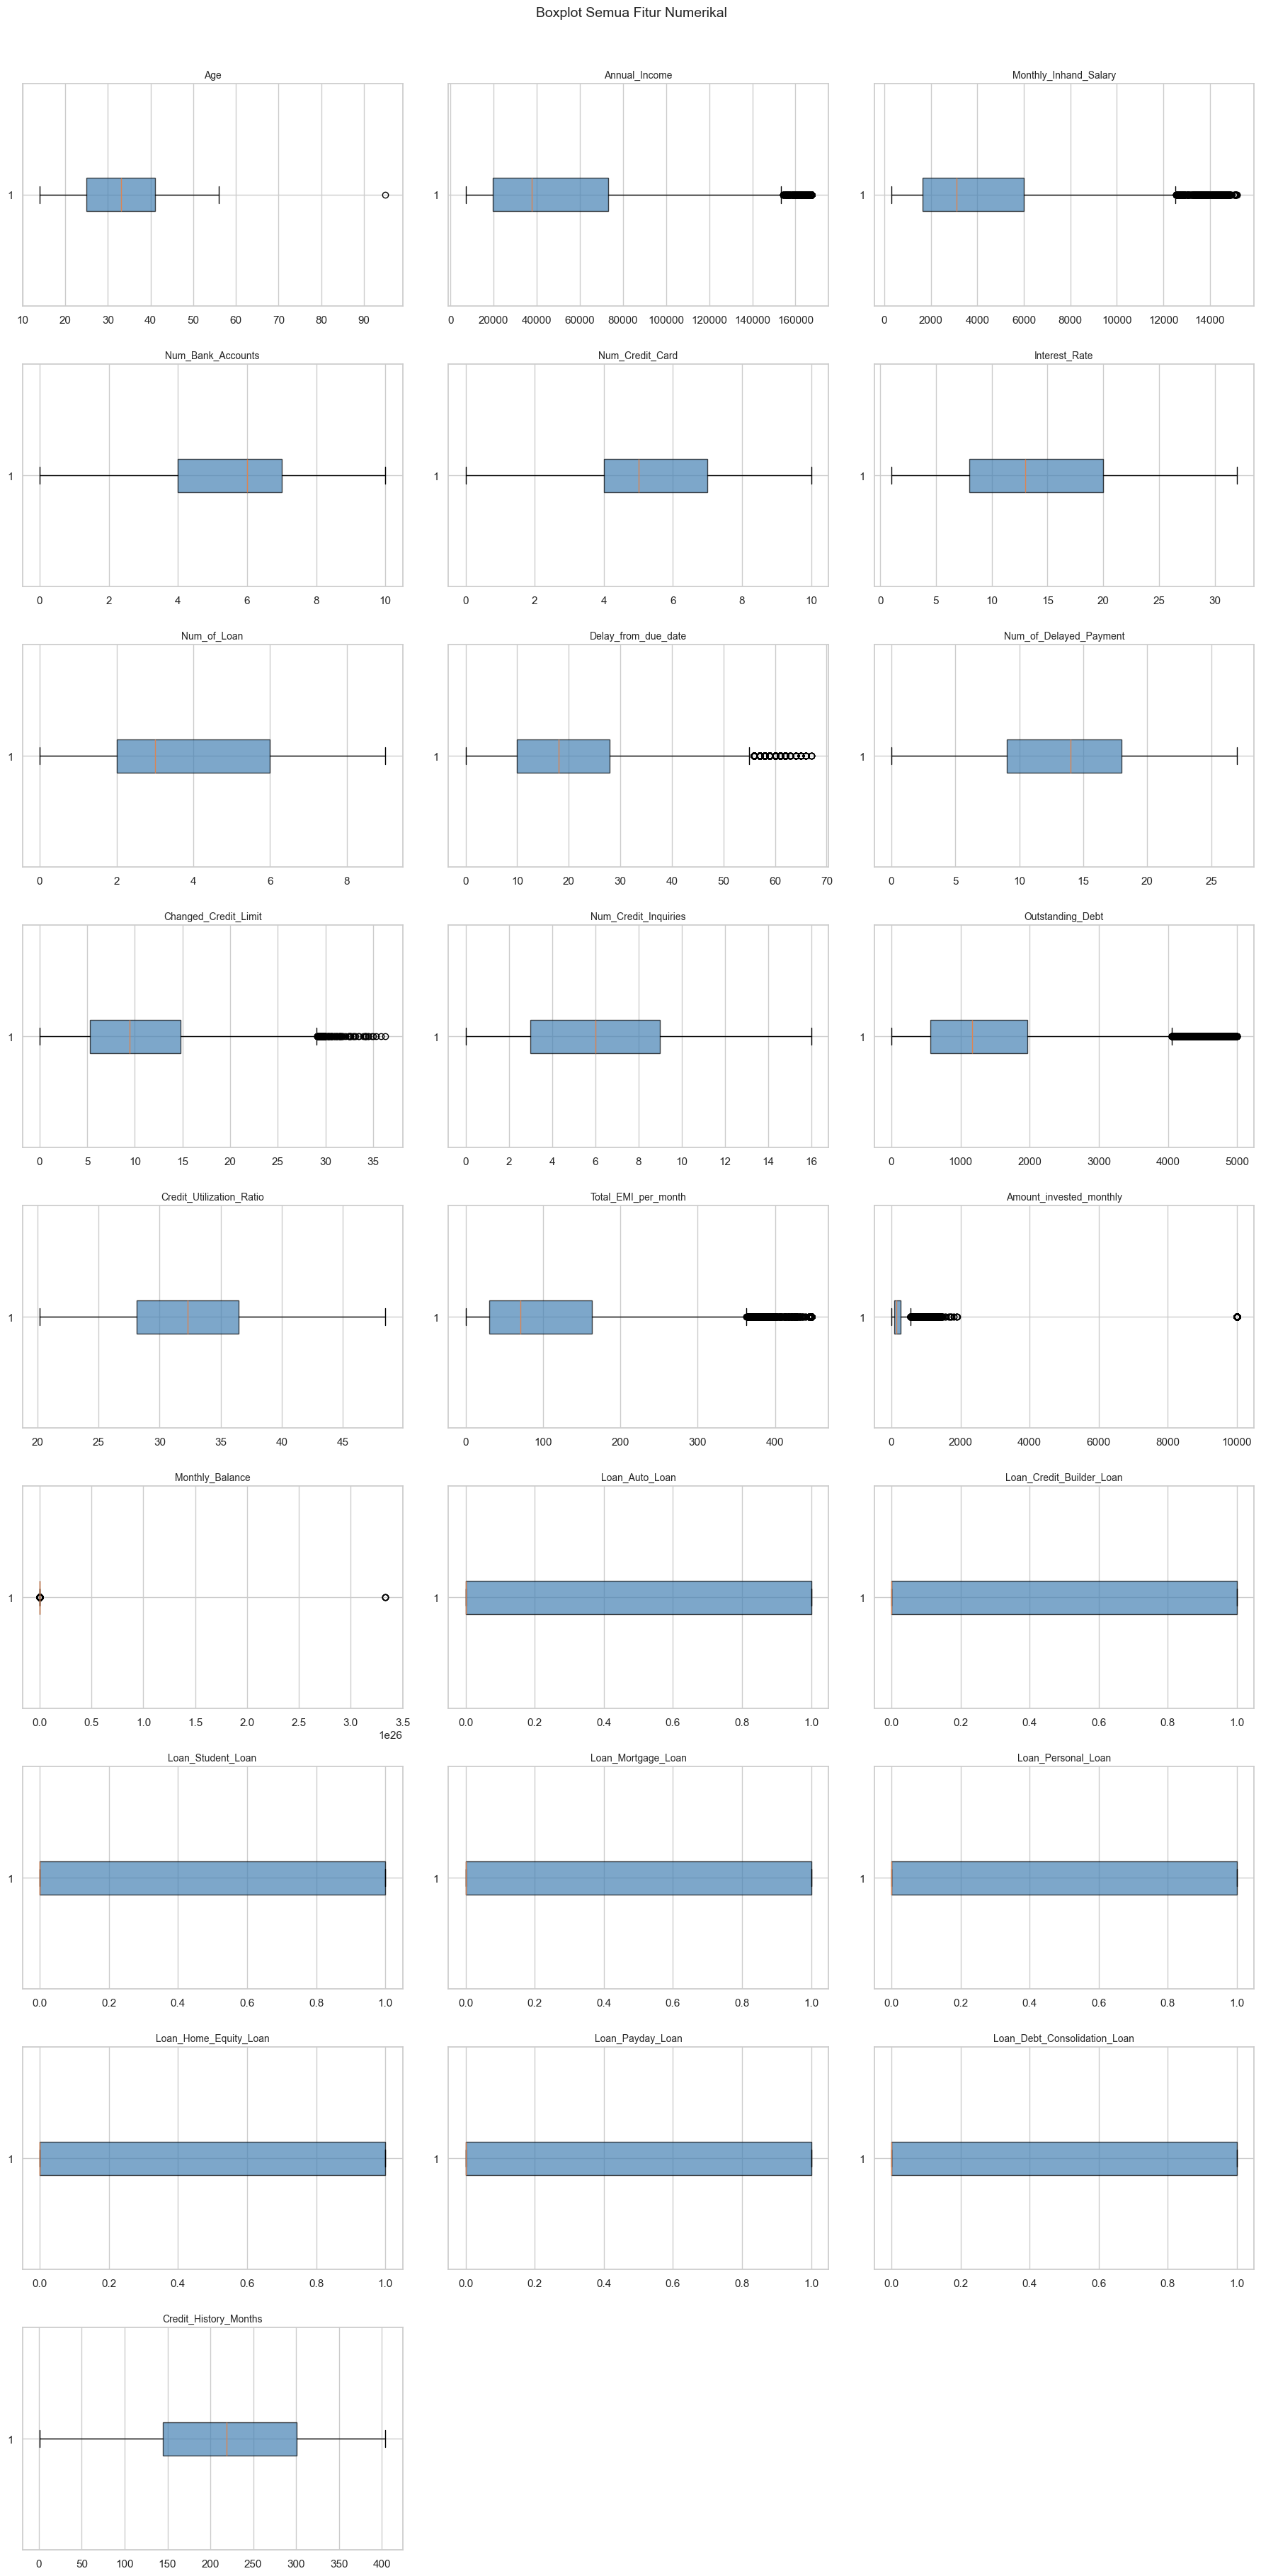

In [38]:
## Distribusi & Boxplot Semua Kolom Numerikal

num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

# --- Histogram ---
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Semua Fitur Numerikal', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# --- Boxplot ---
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].boxplot(data, vert=False, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col, fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot Semua Fitur Numerikal', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Splitting

In [39]:
X = df.drop('Credit_Score', axis=1)
y = df['Credit_Score']

In [40]:
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Classes:", le.classes_)  

Classes: ['Good' 'Poor' 'Standard']


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

## Encoding and Scaling


In [42]:
num_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()
loan_cols = [c for c in X.columns if c.startswith('Loan_')]

In [43]:
num_cols = [c for c in num_cols if c not in loan_cols]

In [44]:
print(f"Num  ({len(num_cols)}): {num_cols}")
print(f"Cat  ({len(cat_cols)}): {cat_cols}")
print(f"Loan ({len(loan_cols)}): {loan_cols}")

Num  (17): ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Months']
Cat  (5): ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
Loan (8): ['Loan_Auto_Loan', 'Loan_Credit_Builder_Loan', 'Loan_Student_Loan', 'Loan_Mortgage_Loan', 'Loan_Personal_Loan', 'Loan_Home_Equity_Loan', 'Loan_Payday_Loan', 'Loan_Debt_Consolidation_Loan']


In [45]:
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

In [46]:
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

In [47]:
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols),
], remainder='passthrough')

## Modelling

In [48]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=300,
        random_state=42
    )
    
}


In [49]:
results = {}

In [50]:
for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipe.fit(X_train, y_train)        
    y_pred = pipe.predict(X_test)       
    f1 = f1_score(y_test, y_pred, average='macro')  

    results[name] = {
        'pipeline': pipe,
        'y_pred': y_pred,
        'f1_macro': f1
    }

    print(f"\n{'='*55}")
    print(f"Model    : {name}")
    print(f"Macro F1 : {f1:.4f}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


Model    : Random Forest
Macro F1 : 0.7142
              precision    recall  f1-score   support

        Good       0.65      0.59      0.62       874
        Poor       0.77      0.71      0.74      1460
    Standard       0.75      0.81      0.78      2666

    accuracy                           0.74      5000
   macro avg       0.73      0.70      0.71      5000
weighted avg       0.74      0.74      0.74      5000


Model    : XGBoost
Macro F1 : 0.6993
              precision    recall  f1-score   support

        Good       0.62      0.61      0.61       874
        Poor       0.74      0.70      0.72      1460
    Standard       0.75      0.77      0.76      2666

    accuracy                           0.72      5000
   macro avg       0.70      0.70      0.70      5000
weighted avg       0.72      0.72      0.72      5000



c:\Users\andro\anaconda3\envs\model_deployment\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Model    : LightGBM
Macro F1 : 0.7000
              precision    recall  f1-score   support

        Good       0.54      0.79      0.64       874
        Poor       0.70      0.78      0.74      1460
    Standard       0.83      0.64      0.72      2666

    accuracy                           0.71      5000
   macro avg       0.69      0.74      0.70      5000
weighted avg       0.74      0.71      0.71      5000


Model    : MLP
Macro F1 : 0.5983
              precision    recall  f1-score   support

        Good       0.49      0.51      0.50       874
        Poor       0.61      0.60      0.61      1460
    Standard       0.69      0.69      0.69      2666

    accuracy                           0.63      5000
   macro avg       0.60      0.60      0.60      5000
weighted avg       0.63      0.63      0.63      5000



# Hyperparameter Tuning & Additional Models

In [51]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPClassifier

## Random Forest - RandomizedSearchCV

In [52]:
rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__max_depth': [None, 10, 20, 30, 40, 50],
    'classifier__min_samples_split': [2, 5, 10, 15],
    'classifier__min_samples_leaf': [1, 2, 4, 8],
}

rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
y_pred = best_rf.predict(X_test)
f1 = f1_score(y_test, y_pred, average='macro')

results['Random Forest (Tuned)'] = {
    'pipeline': best_rf,
    'y_pred': y_pred,
    'f1_macro': f1
}

print(f"\n{'='*55}")
print(f"Model    : Random Forest (Tuned)")
print(f"Best Params: {rf_search.best_params_}")
print(f"Macro F1 : {f1:.4f}")
print(f"{'='*55}")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Model    : Random Forest (Tuned)
Best Params: {'classifier__n_estimators': 400, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': 50}
Macro F1 : 0.7272
              precision    recall  f1-score   support

        Good       0.60      0.72      0.65       874
        Poor       0.75      0.75      0.75      1460
    Standard       0.80      0.75      0.78      2666

    accuracy                           0.75      5000
   macro avg       0.72      0.74      0.73      5000
weighted avg       0.75      0.75      0.75      5000



## XGBoost - RandomizedSearchCV

In [53]:
xgb_param_grid = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'classifier__max_depth': [3, 4, 5, 6, 7, 8],
    'classifier__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
}

xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(eval_metric='mlogloss', random_state=42, n_jobs=-1))
])

xgb_search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=xgb_param_grid,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_
y_pred = best_xgb.predict(X_test)
f1 = f1_score(y_test, y_pred, average='macro')

results['XGBoost (Tuned)'] = {
    'pipeline': best_xgb,
    'y_pred': y_pred,
    'f1_macro': f1
}

print(f"\n{'='*55}")
print(f"Model    : XGBoost (Tuned)")
print(f"Best Params: {xgb_search.best_params_}")
print(f"Macro F1 : {f1:.4f}")
print(f"{'='*55}")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Model    : XGBoost (Tuned)
Best Params: {'classifier__subsample': 0.8, 'classifier__n_estimators': 200, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.2, 'classifier__colsample_bytree': 0.7}
Macro F1 : 0.7119
              precision    recall  f1-score   support

        Good       0.66      0.60      0.63       874
        Poor       0.75      0.72      0.73      1460
    Standard       0.75      0.79      0.77      2666

    accuracy                           0.74      5000
   macro avg       0.72      0.70      0.71      5000
weighted avg       0.74      0.74      0.74      5000



## LightGBM - RandomizedSearchCV

In [54]:
lgb_param_grid = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'classifier__max_depth': [3, 4, 5, 6, 7, -1],
    'classifier__num_leaves': [15, 31, 50, 70, 100],
    'classifier__min_child_samples': [5, 10, 20, 30, 50],
}

lgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lgb.LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1))
])

lgb_search = RandomizedSearchCV(
    lgb_pipe,
    param_distributions=lgb_param_grid,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

lgb_search.fit(X_train, y_train)

best_lgb = lgb_search.best_estimator_
y_pred = best_lgb.predict(X_test)
f1 = f1_score(y_test, y_pred, average='macro')

results['LightGBM (Tuned)'] = {
    'pipeline': best_lgb,
    'y_pred': y_pred,
    'f1_macro': f1
}

print(f"\n{'='*55}")
print(f"Model    : LightGBM (Tuned)")
print(f"Best Params: {lgb_search.best_params_}")
print(f"Macro F1 : {f1:.4f}")
print(f"{'='*55}")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Model    : LightGBM (Tuned)
Best Params: {'classifier__num_leaves': 100, 'classifier__n_estimators': 400, 'classifier__min_child_samples': 10, 'classifier__max_depth': -1, 'classifier__learning_rate': 0.1}
Macro F1 : 0.7180
              precision    recall  f1-score   support

        Good       0.62      0.66      0.64       874
        Poor       0.74      0.75      0.75      1460
    Standard       0.78      0.76      0.77      2666

    accuracy                           0.74      5000
   macro avg       0.71      0.72      0.72      5000
weighted avg       0.74      0.74      0.74      5000



c:\Users\andro\anaconda3\envs\model_deployment\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## MLP Classifier - RandomizedSearchCV

In [55]:
mlp_param_grid = {
    'classifier__hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (100, 100)],
    'classifier__activation': ['relu', 'tanh'],
    'classifier__alpha': [0.0001, 0.001, 0.01, 0.1],
    'classifier__learning_rate_init': [0.001, 0.01, 0.05, 0.1],
}

mlp_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(max_iter=300, random_state=42))
])

mlp_search = RandomizedSearchCV(
    mlp_pipe,
    param_distributions=mlp_param_grid,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

mlp_search.fit(X_train, y_train)

best_mlp = mlp_search.best_estimator_
y_pred = best_mlp.predict(X_test)
f1 = f1_score(y_test, y_pred, average='macro')

results['MLP'] = {
    'pipeline': best_mlp,
    'y_pred': y_pred,
    'f1_macro': f1
}

print(f"\n{'='*55}")
print(f"Model    : MLP")
print(f"Best Params: {mlp_search.best_params_}")
print(f"Macro F1 : {f1:.4f}")
print(f"{'='*55}")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Model    : MLP
Best Params: {'classifier__learning_rate_init': 0.01, 'classifier__hidden_layer_sizes': (50,), 'classifier__alpha': 0.1, 'classifier__activation': 'tanh'}
Macro F1 : 0.6658
              precision    recall  f1-score   support

        Good       0.55      0.60      0.58       874
        Poor       0.71      0.66      0.68      1460
    Standard       0.73      0.74      0.74      2666

    accuracy                           0.69      5000
   macro avg       0.67      0.67      0.67      5000
weighted avg       0.69      0.69      0.69      5000



## Results Summary (All Models)

In [56]:
for name, res in results.items():
    print(f"{name:<25} f1_macro = {res['f1_macro']:.4f}")

Random Forest             f1_macro = 0.7142
XGBoost                   f1_macro = 0.6993
LightGBM                  f1_macro = 0.7000
MLP                       f1_macro = 0.6658
Random Forest (Tuned)     f1_macro = 0.7272
XGBoost (Tuned)           f1_macro = 0.7119
LightGBM (Tuned)          f1_macro = 0.7180


##